# CCLE TP53 Classifier: Confounding-aware Global Analysis


## Notebook goals

This revision implements the confounding-aware global-analysis pipeline. The lineage-routed
mixture-of-experts branch from the earlier revision has been removed: after comparing its
held-out test metrics against the primary clean RNA-only model under matched bootstrap CIs,
the added complexity was not justified by a reliable performance gain.

The headline scientific question is:

> **Does RNA expression predict TP53 mutation status beyond lineage structure?**

Models compared in the registry:
- dummy prior baseline
- lineage-only logistic regression (confounding baseline)
- RNA-only models (L2 LR, elastic-net LR, linear SVM, PCA + LR, PCA + SVM, random forest, LightGBM if available)
- RNA + lineage model
- lineage-residualized RNA model
- validation-locked RNA-only soft-vote ensemble

Additional analyses (each is a section below):
- per-lineage test performance breakdown for the primary clean model
- top-feature composition (TP53 targets vs lineage markers vs other)
- outlier sensitivity analysis
- calibration diagnostic (reliability curve + Brier score)
- label-strictness sensitivity (`TP53_mut_any`, `TP53_mut_nonsyn`, `TP53_mut_lof`)
- nested grouped CV with lineage as the grouping variable

Safeguards inherited from the EDA:
- split first, then filter / transform (train-only filtering)
- supervised selection lives inside sklearn Pipelines so it is refit per CV fold
- prefer raw-expression reconstruction when available; fall back to EDA-selected features with a loud warning
- report AUPRC as the primary metric, with AUROC, balanced accuracy, F1, precision, recall, specificity alongside
- bootstrap 95% CIs on key test metrics, stratified on class


## 0. Setup

In [1]:
from pathlib import Path
from IPython.display import display
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RNG = 42
DATA_DIR = Path("data")
PROC = Path("processed")
PROC.mkdir(exist_ok=True, parents=True)

CONFIG = {
    "label_col_preferred": "TP53_mut_nonsyn",
    "detect_expr_threshold": 0.10,
    "min_detect_frac": 0.05,
    "min_variance": 1e-4,
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "drop_sure_outliers": False,
    "min_lineage_n_report": 15,
    "min_lineage_n_eval": 10,
    "cv_splits": 5,
    "cv_scoring": "average_precision",
    "ensemble_top_k": 3,
    "bootstrap_reps": 1000,
    "grouped_outer_splits": 5,
    "grouped_inner_splits": 3,
    "top_k_for_interpretation": 30,
    "alt_labels_for_sensitivity": ["TP53_mut_any", "TP53_mut_nonsyn", "TP53_mut_lof"],
    "label_sensitivity_models": ["lineage_logreg", "selected_l2_logreg", "selected_enet_logreg"],
}

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}
LINEAGE_MARKER_HINTS = {"EPCAM", "CLDN7", "KRT19", "KRT8", "KRT18", "MUC1"}

# Families that need the lineage column at transform / inference time.
LINEAGE_DEPENDENT_FAMILIES = {"lineage", "rna_plus_lineage", "rna_residualized"}

print(json.dumps(CONFIG, indent=2))


{
  "label_col_preferred": "TP53_mut_nonsyn",
  "detect_expr_threshold": 0.1,
  "min_detect_frac": 0.05,
  "min_variance": 0.0001,
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "drop_sure_outliers": false,
  "min_lineage_n_report": 15,
  "min_lineage_n_eval": 10,
  "cv_splits": 5,
  "cv_scoring": "average_precision",
  "ensemble_top_k": 3,
  "bootstrap_reps": 1000,
  "grouped_outer_splits": 5,
  "grouped_inner_splits": 3,
  "top_k_for_interpretation": 30,
  "alt_labels_for_sensitivity": [
    "TP53_mut_any",
    "TP53_mut_nonsyn",
    "TP53_mut_lof"
  ],
  "label_sensitivity_models": [
    "lineage_logreg",
    "selected_l2_logreg",
    "selected_enet_logreg"
  ]
}


### Data loading and correlation helpers

In [2]:
def choose_first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def collapse_duplicate_gene_columns(df):
    n_dup = int(df.columns.duplicated().sum())
    if n_dup == 0:
        return df, 0
    collapsed = df.T.groupby(level=0).mean().T
    return collapsed, n_dup


def load_parquet_with_id(path, id_col="ModelID"):
    df = pd.read_parquet(path)
    if id_col not in df.columns:
        raise ValueError(f"{path} is missing required ID column {id_col}")
    df[id_col] = df[id_col].astype(str)
    return df.set_index(id_col)


def load_txt_ids(path, id_col="ModelID"):
    if not path.exists():
        return pd.Index([], dtype="object", name=id_col)
    s = pd.read_csv(path)
    if s.shape[1] == 0:
        return pd.Index([], dtype="object", name=id_col)
    return pd.Index(s.iloc[:, 0].astype(str), name=id_col)


def corr_against_binary(X, y, method="pearson"):
    assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame"
    y = pd.Series(y, index=X.index).astype(float)
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r**2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def save_parquet_with_id(df, filename, id_col="ModelID"):
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(PROC / filename, index=False)


def save_series_with_id(s, filename, id_col="ModelID"):
    out = s.rename_axis(id_col).reset_index()
    out.to_parquet(PROC / filename, index=False)


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


### Custom sklearn transformers

In [3]:
class CorrTargetGeneSelector(BaseEstimator, TransformerMixin):
    """Supervised gene selector: union of top-|Pearson r| genes and a curated target list.

    Fits on a training fold only (caller's responsibility via Pipeline), so usage inside
    GridSearchCV refits the selection per inner CV fold.
    """

    def __init__(
        self,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame.")

        y = pd.Series(y, index=X.index).astype(int)
        pear = corr_against_binary(X, y, method="pearson")
        spear = corr_against_binary(X, y, method="spearman")
        corr = pear.join(spear)
        corr["abs_pearson_r"] = corr["pearson_r"].abs()
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

        corr_ranked = corr.loc[
            (corr["pearson_p_bh"] <= self.corr_alpha)
            & (corr["spearman_p_bh"] <= self.corr_alpha)
            & (corr["abs_pearson_r"] >= self.corr_min_abs_r)
        ].sort_values("abs_pearson_r", ascending=False)

        set_corr = set(corr_ranked.head(self.max_corr_features).index)

        targets_present = set()
        for gene in sorted(self.tp53_targets or []):
            if gene in X.columns:
                targets_present.add(gene)
            elif self.target_aliases and gene in self.target_aliases and self.target_aliases[gene] in X.columns:
                targets_present.add(self.target_aliases[gene])

        selected = sorted(set_corr | targets_present)
        if len(selected) == 0:
            raise ValueError("Supervised selection produced zero genes. Relax thresholds or inspect the training fold.")

        manifest = pd.DataFrame(index=selected)
        manifest["from_correlation"] = manifest.index.isin(set_corr)
        manifest["from_tp53_target_list"] = manifest.index.isin(targets_present)
        manifest["pearson_r"] = corr.reindex(manifest.index)["pearson_r"]
        manifest["spearman_r"] = corr.reindex(manifest.index)["spearman_r"]
        manifest["abs_pearson_r"] = manifest["pearson_r"].abs()
        manifest["corr_rank"] = manifest["abs_pearson_r"].rank(method="dense", ascending=False)

        self.selected_genes_ = selected
        self.selection_manifest_ = manifest.sort_values("abs_pearson_r", ascending=False)
        self.corr_full_ = corr.sort_values("abs_pearson_r", ascending=False)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame.")
        missing = [g for g in self.selected_genes_ if g not in X.columns]
        if missing:
            raise ValueError(f"Missing selected genes at transform time, first few: {missing[:10]}")
        return X.loc[:, self.selected_genes_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_genes_, dtype=object)


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Fold rare categorical values into 'Other' based on training counts."""

    def __init__(self, min_n=15, other_label="Other"):
        self.min_n = min_n
        self.other_label = other_label

    def fit(self, X, y=None):
        X_df = self._to_frame(X)
        self.feature_name_in_ = X_df.columns[0]
        s = X_df.iloc[:, 0].fillna("Unknown").astype(str)
        counts = s.value_counts()
        self.category_counts_ = counts
        self.major_categories_ = set(counts[counts >= self.min_n].index.tolist())
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        s = X_df.iloc[:, 0].fillna("Unknown").astype(str)
        s = s.where(s.isin(self.major_categories_), other=self.other_label)
        return pd.DataFrame({self.feature_name_in_: s}, index=X_df.index)

    def get_feature_names_out(self, input_features=None):
        return np.array([self.feature_name_in_], dtype=object)

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.Series):
            return X.to_frame()
        if isinstance(X, pd.DataFrame):
            if X.shape[1] != 1:
                raise ValueError("RareCategoryGrouper expects exactly one column.")
            return X
        raise TypeError("RareCategoryGrouper expects a pandas Series or single-column DataFrame.")


class GeneLineageFeatureBuilder(BaseEstimator, TransformerMixin):
    """Build a combined feature matrix of supervised-selected genes plus one-hot lineage."""

    def __init__(
        self,
        lineage_col,
        min_lineage_n=15,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.lineage_col = lineage_col
        self.min_lineage_n = min_lineage_n
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("GeneLineageFeatureBuilder expects a pandas DataFrame.")
        if self.lineage_col not in X.columns:
            raise ValueError(f"Missing lineage column: {self.lineage_col}")

        gene_df = X.drop(columns=[self.lineage_col])
        self.gene_selector_ = CorrTargetGeneSelector(
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.gene_selector_.fit(gene_df, y)

        self.lineage_grouper_ = RareCategoryGrouper(min_n=self.min_lineage_n)
        self.lineage_grouper_.fit(X[[self.lineage_col]])
        lineage_collapsed = self.lineage_grouper_.transform(X[[self.lineage_col]])

        self.lineage_encoder_ = make_dense_onehot_encoder()
        self.lineage_encoder_.fit(lineage_collapsed)

        self.gene_feature_names_ = list(self.gene_selector_.get_feature_names_out())
        self.lineage_feature_names_ = [
            f"{self.lineage_col}__{cat}" for cat in self.lineage_encoder_.categories_[0]
        ]
        self.feature_names_out_ = np.array(self.gene_feature_names_ + self.lineage_feature_names_, dtype=object)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("GeneLineageFeatureBuilder expects a pandas DataFrame.")
        gene_df = X.drop(columns=[self.lineage_col])
        gene_arr = self.gene_selector_.transform(gene_df).to_numpy(dtype=float)
        lineage_collapsed = self.lineage_grouper_.transform(X[[self.lineage_col]])
        lineage_arr = self.lineage_encoder_.transform(lineage_collapsed)
        return np.hstack([gene_arr, lineage_arr])

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_


class LineageResidualizer(BaseEstimator, TransformerMixin):
    """Remove lineage-associated mean structure from gene expression.

    Expects a pandas DataFrame with gene-expression columns plus one categorical lineage
    column. Fits the lineage effect on the training data only, then returns residualized
    gene-expression values. The ridge term is a tiny numerical safety factor.
    """

    def __init__(self, lineage_col, min_lineage_n=15, alpha=1e-6):
        self.lineage_col = lineage_col
        self.min_lineage_n = min_lineage_n
        self.alpha = alpha

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("LineageResidualizer expects a pandas DataFrame.")
        if self.lineage_col not in X.columns:
            raise ValueError(f"Missing lineage column: {self.lineage_col}")

        gene_df = X.drop(columns=[self.lineage_col]).copy()
        lineage_df = X[[self.lineage_col]].copy()

        self.gene_columns_ = list(gene_df.columns)
        self.lineage_grouper_ = RareCategoryGrouper(min_n=self.min_lineage_n)
        self.lineage_grouper_.fit(lineage_df)
        lineage_collapsed = self.lineage_grouper_.transform(lineage_df)

        self.lineage_encoder_ = make_dense_onehot_encoder()
        Z = self.lineage_encoder_.fit_transform(lineage_collapsed)
        Z = np.asarray(Z, dtype=float)
        Z = np.column_stack([np.ones(len(lineage_collapsed), dtype=float), Z])

        X_gene = gene_df.to_numpy(dtype=float)
        ridge = self.alpha * np.eye(Z.shape[1], dtype=float)
        ridge[0, 0] = 0.0
        self.coef_ = np.linalg.solve(Z.T @ Z + ridge, Z.T @ X_gene)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("LineageResidualizer expects a pandas DataFrame.")
        if self.lineage_col not in X.columns:
            raise ValueError(f"Missing lineage column: {self.lineage_col}")

        gene_df = X[self.gene_columns_].copy()
        lineage_df = self.lineage_grouper_.transform(X[[self.lineage_col]].copy())
        Z = self.lineage_encoder_.transform(lineage_df)
        Z = np.asarray(Z, dtype=float)
        Z = np.column_stack([np.ones(len(lineage_df), dtype=float), Z])
        fitted = Z @ self.coef_
        resid = gene_df.to_numpy(dtype=float) - fitted
        return pd.DataFrame(resid, index=X.index, columns=self.gene_columns_)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.gene_columns_, dtype=object)


### Pipeline factories

All factories now take `data_mode` and `lineage_col` as explicit arguments rather than reading them from the enclosing module scope — so they cannot silently pick up the wrong setting if called out of order.

In [4]:
def make_selected_pipeline(clf, data_mode, scale=True,
                           tp53_targets=TP53_TARGETS, target_aliases=TARGET_ALIASES):
    steps = []
    if data_mode == "raw_reconstructed":
        steps.append((
            "select",
            CorrTargetGeneSelector(
                corr_alpha=CONFIG["corr_alpha"],
                corr_min_abs_r=CONFIG["corr_min_abs_r"],
                max_corr_features=CONFIG["max_corr_features"],
                tp53_targets=tp53_targets,
                target_aliases=target_aliases,
            ),
        ))
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps)


def make_pca_pipeline(clf):
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(svd_solver="full", random_state=RNG)),
        ("clf", clf),
    ])


def make_lineage_pipeline(clf):
    return Pipeline([
        ("rare", RareCategoryGrouper(min_n=CONFIG["min_lineage_n_report"])),
        ("onehot", make_dense_onehot_encoder()),
        ("clf", clf),
    ])


def make_rna_lineage_pipeline(clf, lineage_col, scale=True):
    if lineage_col is None:
        raise ValueError("lineage_col is required for make_rna_lineage_pipeline.")
    steps = [(
        "build",
        GeneLineageFeatureBuilder(
            lineage_col=lineage_col,
            min_lineage_n=CONFIG["min_lineage_n_report"],
            corr_alpha=CONFIG["corr_alpha"],
            corr_min_abs_r=CONFIG["corr_min_abs_r"],
            max_corr_features=CONFIG["max_corr_features"],
            tp53_targets=TP53_TARGETS,
            target_aliases=TARGET_ALIASES,
        ),
    )]
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps)


def make_residualized_pipeline(clf, lineage_col, data_mode, scale=True):
    if lineage_col is None:
        raise ValueError("lineage_col is required for make_residualized_pipeline.")
    steps = [(
        "residualize",
        LineageResidualizer(
            lineage_col=lineage_col,
            min_lineage_n=CONFIG["min_lineage_n_report"],
        ),
    )]
    if data_mode == "raw_reconstructed":
        steps.append((
            "select",
            CorrTargetGeneSelector(
                corr_alpha=CONFIG["corr_alpha"],
                corr_min_abs_r=CONFIG["corr_min_abs_r"],
                max_corr_features=CONFIG["max_corr_features"],
                tp53_targets=TP53_TARGETS,
                target_aliases=TARGET_ALIASES,
            ),
        ))
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps)


### CV utilities, metrics, and bootstrap

In [5]:
def choose_threshold(y_true, prob, metric_fn=balanced_accuracy_score):
    """Grid-search a probability threshold that maximises `metric_fn(y_true, y_pred)`."""
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        scores.append(metric_fn(y_true, pred))
    return float(thresholds[int(np.argmax(scores))])


def evaluate_probs(y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "model": model_name,
        "split": split_name,
        "threshold": float(threshold),
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": specificity,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def stratified_bootstrap_ci(y_true, prob, metric_fn, n_boot=1000, seed=42):
    y_true = pd.Series(y_true).reset_index(drop=True)
    prob = pd.Series(prob).reset_index(drop=True)
    pos_idx = np.flatnonzero(y_true.to_numpy() == 1)
    neg_idx = np.flatnonzero(y_true.to_numpy() == 0)
    rng = np.random.default_rng(seed)

    results = []
    for _ in range(n_boot):
        boot_idx = np.concatenate([
            rng.choice(pos_idx, size=len(pos_idx), replace=True),
            rng.choice(neg_idx, size=len(neg_idx), replace=True),
        ])
        boot_y = y_true.iloc[boot_idx]
        boot_p = prob.iloc[boot_idx]
        if boot_y.nunique() < 2:
            continue
        results.append(metric_fn(boot_y, boot_p))

    if len(results) == 0:
        return np.nan, np.nan
    lo, hi = np.quantile(results, [0.025, 0.975])
    return float(lo), float(hi)


def infer_probabilities(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        raw = fitted_model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    raise AttributeError("Model has neither predict_proba nor decision_function.")


def count_effective_features(fitted_model, family=None):
    """Count nonzero linear coefficients. Returns NaN for tree-based families because
    feature_importances_ is rarely exactly zero and the count would be misleading."""
    clf = (
        fitted_model.named_steps["clf"]
        if hasattr(fitted_model, "named_steps") and "clf" in fitted_model.named_steps
        else fitted_model
    )
    if family is not None and family.startswith("rna_tree"):
        return np.nan
    if hasattr(clf, "coef_"):
        return int(np.count_nonzero(np.abs(np.ravel(clf.coef_)) > 1e-12))
    return np.nan


def fit_search_validate(name, spec, X_train, y_train, X_val, y_val, cv):
    search = GridSearchCV(
        estimator=clone(spec["estimator"]),
        param_grid=spec["param_grid"],
        scoring=CONFIG["cv_scoring"],
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_
    val_prob = infer_probabilities(best_estimator, X_val)
    threshold = choose_threshold(y_val, val_prob)

    row = evaluate_probs(y_val, val_prob, threshold, "val", name)
    row["cv_score_name"] = CONFIG["cv_scoring"]
    row["cv_best_score"] = float(search.best_score_)
    row["n_effective_features"] = count_effective_features(best_estimator, family=spec["family"])
    row["family"] = spec["family"]
    row["ensemble_eligible"] = bool(spec.get("ensemble_eligible", False))

    obj = {
        "model": best_estimator,
        "threshold": threshold,
        "best_params": search.best_params_,
        "cv_best_score": float(search.best_score_),
        "val_prob": val_prob,
        "family": spec["family"],
        "ensemble_eligible": bool(spec.get("ensemble_eligible", False)),
        "description": spec.get("description", ""),
    }
    return row, obj


def run_grouped_nested_cv(model_name, spec, X, y, groups, outer_splits=5, inner_splits=3, random_state=42):
    groups = pd.Series(groups, index=X.index).fillna("Unknown").astype(str)
    y = pd.Series(y, index=X.index).astype(int)

    n_groups = groups.nunique()
    max_by_class = int(y.value_counts().min())
    outer_eff = min(outer_splits, n_groups, max_by_class)
    if outer_eff < 2:
        raise ValueError("Not enough grouped class diversity for grouped CV.")

    outer = StratifiedGroupKFold(n_splits=outer_eff, shuffle=True, random_state=random_state)
    fold_frames = []
    fold_rows = []

    for fold_id, (tr_idx, te_idx) in enumerate(outer.split(X, y, groups=groups), start=1):
        X_tr = X.iloc[tr_idx]
        X_te = X.iloc[te_idx]
        y_tr = y.iloc[tr_idx]
        y_te = y.iloc[te_idx]
        g_tr = groups.iloc[tr_idx]
        g_te = groups.iloc[te_idx]

        inner_eff = min(inner_splits, g_tr.nunique(), int(y_tr.value_counts().min()))
        if inner_eff < 2:
            continue

        inner = StratifiedGroupKFold(n_splits=inner_eff, shuffle=True, random_state=random_state + fold_id)
        search = GridSearchCV(
            estimator=clone(spec["estimator"]),
            param_grid=spec["param_grid"],
            scoring=CONFIG["cv_scoring"],
            cv=inner,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_tr, y_tr, groups=g_tr)
        prob = infer_probabilities(search.best_estimator_, X_te)
        threshold = 0.5
        row = evaluate_probs(y_te, prob, threshold, f"grouped_fold_{fold_id}", model_name)
        row["fold"] = fold_id
        row["n_groups_test"] = int(g_te.nunique())
        row["cv_best_score"] = float(search.best_score_)
        fold_rows.append(row)
        fold_frames.append(
            pd.DataFrame(
                {
                    "model": model_name,
                    "fold": fold_id,
                    "group": g_te.values,
                    "y_true": y_te.values,
                    "prob": prob,
                },
                index=X_te.index,
            )
        )

    if not fold_frames:
        raise ValueError("Grouped CV did not produce any valid folds.")

    pred_df = pd.concat(fold_frames).sort_index()
    pooled_threshold = choose_threshold(pred_df["y_true"], pred_df["prob"])
    summary = evaluate_probs(pred_df["y_true"], pred_df["prob"], pooled_threshold, "grouped_cv", model_name)
    summary["family"] = spec["family"]
    summary["n_outer_folds"] = int(pred_df["fold"].nunique())
    summary["n_samples"] = int(len(pred_df))
    summary["mean_fold_cv_best_score"] = float(np.mean([row["cv_best_score"] for row in fold_rows]))
    return summary, pred_df, pd.DataFrame(fold_rows)


### Ensembling, model selection, and interpretation helpers

In [6]:
def get_top_validation_models(val_results, n=3, eligible_only=True,
                              exclude_prefixes=None, exclude_models=None):
    df = val_results.copy()
    exclude_models = set(exclude_models or [])
    exclude_prefixes = tuple(exclude_prefixes or [])
    if eligible_only and "ensemble_eligible" in df.columns:
        df = df.loc[df["ensemble_eligible"].fillna(False)].copy()
    if exclude_models:
        df = df.loc[~df["model"].isin(exclude_models)].copy()
    if exclude_prefixes:
        df = df.loc[~df["model"].astype(str).str.startswith(exclude_prefixes)].copy()
    return (
        df.sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)["model"]
        .head(n)
        .tolist()
    )


def fit_validation_locked_soft_vote(member_names, validation_objects, y_val,
                                    model_name="soft_vote_topk"):
    if len(member_names) < 2:
        raise ValueError("Need at least two members for a soft-vote ensemble.")
    val_prob = np.mean(
        [np.asarray(validation_objects[m]["val_prob"], dtype=float) for m in member_names],
        axis=0,
    )
    threshold = choose_threshold(y_val, val_prob)
    row = evaluate_probs(y_val, val_prob, threshold, "val", model_name)
    row["cv_score_name"] = CONFIG["cv_scoring"]
    row["cv_best_score"] = float(np.mean([validation_objects[m]["cv_best_score"] for m in member_names]))
    row["n_effective_features"] = np.nan
    row["family"] = "ensemble_soft_vote"
    row["ensemble_eligible"] = False
    obj = {
        "model": {"members": member_names},
        "threshold": threshold,
        "best_params": {m: validation_objects[m]["best_params"] for m in member_names},
        "cv_best_score": row["cv_best_score"],
        "val_prob": val_prob,
        "family": "ensemble_soft_vote",
        "ensemble_eligible": False,
        "description": f"Validation-locked soft-vote ensemble of {member_names}",
        "members": member_names,
    }
    return row, obj


def fit_final_validation_locked_soft_vote(soft_vote_obj, candidate_specs, validation_objects, y_trva):
    member_probs = []
    fitted_members = {}
    member_names = list(soft_vote_obj["members"])
    for member in member_names:
        spec = candidate_specs[member]
        fitted = clone(spec["estimator"]).set_params(**validation_objects[member]["best_params"])
        fitted.fit(spec["trva_X"], y_trva)
        fitted_members[member] = fitted
        member_probs.append(infer_probabilities(fitted, spec["test_X"]))
    return {
        "members": member_names,
        "fitted_members": fitted_members,
        "test_prob": np.mean(member_probs, axis=0),
    }


def family_uses_lineage_at_inference(family):
    """True if a model's family needs the lineage column at transform/predict time."""
    return family in LINEAGE_DEPENDENT_FAMILIES


def choose_primary_clean_model(val_results):
    """Best truly RNA-only model at inference time.

    Excludes the dummy baseline, every lineage-dependent family (lineage-only,
    RNA+lineage, and the residualized model which needs lineage at transform time),
    and any ensembles whose members require lineage.
    """
    mask = (
        ~val_results["family"].isin({"baseline"} | LINEAGE_DEPENDENT_FAMILIES)
        & ~val_results["model"].astype(str).str.startswith("routed_")
    )
    clean = val_results.loc[mask].copy()
    if clean.empty:
        return None
    clean = clean.sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)
    return clean.iloc[0]["model"]


def extract_linear_feature_table(fitted_model, lineage_col=None, selected_feature_fallback=None):
    """Return a tidy coefficient table for linear models, annotated with TP53-target and
    lineage-marker flags. Lineage-encoded one-hot columns are flagged as such."""
    if not hasattr(fitted_model, "named_steps") or "clf" not in fitted_model.named_steps:
        return None

    clf = fitted_model.named_steps["clf"]
    if not hasattr(clf, "coef_"):
        return None

    if "select" in fitted_model.named_steps:
        feature_names = list(fitted_model.named_steps["select"].get_feature_names_out())
        manifest = fitted_model.named_steps["select"].selection_manifest_.reindex(feature_names)
    elif "build" in fitted_model.named_steps:
        builder = fitted_model.named_steps["build"]
        feature_names = list(builder.get_feature_names_out())
        manifest = None
    elif "residualize" in fitted_model.named_steps:
        feature_names = list(fitted_model.named_steps["residualize"].get_feature_names_out())
        manifest = None
    elif selected_feature_fallback is not None:
        feature_names = list(selected_feature_fallback)
        manifest = None
    else:
        feature_names = [f"feature_{i}" for i in range(clf.coef_.shape[1])]
        manifest = None

    coef = pd.Series(np.ravel(clf.coef_), index=feature_names, name="coefficient")
    coef_table = coef.to_frame()
    coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
    coef_table["tp53_target_gene"] = coef_table.index.isin(
        {g if g != "WIG1" else "ZMAT3" for g in TP53_TARGETS}
    )
    coef_table["lineage_marker_hint"] = coef_table.index.isin(LINEAGE_MARKER_HINTS)
    if lineage_col is not None:
        coef_table["lineage_encoded_feature"] = (
            coef_table.index.to_series().str.startswith(f"{lineage_col}__")
        )
    else:
        coef_table["lineage_encoded_feature"] = False

    if manifest is not None:
        coef_table["from_correlation_screen"] = manifest["from_correlation"].values
        coef_table["from_tp53_target_list"] = manifest["from_tp53_target_list"].values

    return coef_table.sort_values("abs_coefficient", ascending=False)


def pca_gene_space_weights(fitted_pipeline):
    """Back-project PCA-logreg coefficients into gene space. Returns a pandas Series of
    implicit per-gene weights, sorted by |weight|."""
    if not hasattr(fitted_pipeline, "named_steps"):
        return None
    if "pca" not in fitted_pipeline.named_steps or "clf" not in fitted_pipeline.named_steps:
        return None
    clf = fitted_pipeline.named_steps["clf"]
    if not hasattr(clf, "coef_"):
        return None
    pca = fitted_pipeline.named_steps["pca"]
    gene_weights = np.ravel(clf.coef_) @ pca.components_
    scale_step = fitted_pipeline.named_steps.get("scale", None)
    if scale_step is not None and hasattr(scale_step, "get_feature_names_out"):
        feature_names = scale_step.get_feature_names_out()
    else:
        feature_names = [f"feature_{i}" for i in range(len(gene_weights))]
    return pd.Series(gene_weights, index=feature_names, name="implicit_gene_weight").sort_values(
        key=np.abs, ascending=False
    )


## 1. Load metadata, labels, split membership, and expression data

In [7]:
required_processed = [
    PROC / "ccle_sample_metadata.parquet",
    PROC / "ccle_split_membership.parquet",
]
for path in required_processed:
    if not path.exists():
        raise FileNotFoundError(f"Required processed artifact missing: {path}")

sample_meta = load_parquet_with_id(PROC / "ccle_sample_metadata.parquet")
split_membership = load_parquet_with_id(PROC / "ccle_split_membership.parquet")
if split_membership.shape[1] != 1:
    raise ValueError("Expected split_membership parquet to contain exactly one non-ID column.")
split_col = split_membership.columns[0]
split_membership = split_membership[split_col].astype(str)

sample_meta = sample_meta.join(split_membership.rename("split"), how="inner", rsuffix="_from_split")
label_col = (
    CONFIG["label_col_preferred"]
    if CONFIG["label_col_preferred"] in sample_meta.columns
    else "TP53_mut_any"
)
lineage_col = choose_first_present(
    sample_meta.columns,
    ["OncotreeLineage", "OncotreeLineageDerived", "Lineage", "lineage"],
)

print(f"Label used for modelling: {label_col}")
print(f"Lineage column used:      {lineage_col}")
print(sample_meta["split"].value_counts().sort_index())

y_all = sample_meta[label_col].astype(int)

# Preferred path: reconstruct full matrices from raw expression data so that supervised
# feature selection happens inside each inner CV fold rather than once globally.
expr_path = DATA_DIR / "OmicsExpressionProteinCodingGenesTPMLogp1.csv"
has_raw_expression = expr_path.exists()

if has_raw_expression:
    expr = pd.read_csv(expr_path, index_col=0)
    expr.index = expr.index.astype(str)
    expr.index.name = "ModelID"
    expr.columns = expr.columns.str.replace(r"\s*\([^)]*\)$", "", regex=True)
    expr, n_collapsed_gene_names = collapse_duplicate_gene_columns(expr)

    common_ids = sample_meta.index.intersection(expr.index)
    if len(common_ids) != len(sample_meta):
        warnings.warn(
            f"Expression overlap smaller than sample metadata: {len(common_ids)} / {len(sample_meta)} samples retained."
        )
    sample_meta = sample_meta.loc[common_ids].copy()
    y_all = y_all.loc[common_ids]
    X_all = expr.loc[common_ids].copy()

    X_train_raw = X_all.loc[sample_meta.index[sample_meta["split"].eq("train")]].copy()
    X_val_raw = X_all.loc[sample_meta.index[sample_meta["split"].eq("val")]].copy()
    X_test_raw = X_all.loc[sample_meta.index[sample_meta["split"].eq("test")]].copy()

    y_train = y_all.loc[X_train_raw.index].copy()
    y_val = y_all.loc[X_val_raw.index].copy()
    y_test = y_all.loc[X_test_raw.index].copy()

    detected_frac = (X_train_raw > CONFIG["detect_expr_threshold"]).mean(axis=0)
    variance = X_train_raw.var(axis=0, ddof=1)
    keep_gene_mask = (
        (detected_frac >= CONFIG["min_detect_frac"])
        & (variance >= CONFIG["min_variance"])
    )

    X_train_filt = X_train_raw.loc[:, keep_gene_mask].copy()
    X_val_filt = X_val_raw.loc[:, keep_gene_mask].copy()
    X_test_filt = X_test_raw.loc[:, keep_gene_mask].copy()

    sure_outliers = load_txt_ids(PROC / "ccle_sure_outliers.txt")
    sure_outliers = sure_outliers.intersection(X_train_filt.index)
    if CONFIG["drop_sure_outliers"] and len(sure_outliers) > 0:
        X_train_model = X_train_filt.drop(index=sure_outliers)
        y_train_model = y_train.drop(index=sure_outliers)
    else:
        X_train_model = X_train_filt.copy()
        y_train_model = y_train.copy()

    data_mode = "raw_reconstructed"
    print(f"Using raw-expression reconstruction path. Duplicate gene symbols collapsed: {n_collapsed_gene_names}")
    print(f"Genes before filtering: {X_train_raw.shape[1]:,}")
    print(f"Genes after filtering:  {X_train_filt.shape[1]:,}")
else:
    warnings.warn(
        "Raw expression file not found. Falling back to EDA-selected feature matrices. "
        "In this mode feature selection is globally pre-computed (not refit per CV fold), "
        "so validation and test numbers inherit the EDA's globally-selected-genes caveat. "
        "Re-run with the raw expression file present to get fold-safe feature selection."
    )
    X_train_model = load_parquet_with_id(PROC / "ccle_X_train_selected.parquet")
    X_val_filt = load_parquet_with_id(PROC / "ccle_X_val_selected.parquet")
    X_test_filt = load_parquet_with_id(PROC / "ccle_X_test_selected.parquet")

    y_train = y_all.loc[X_train_model.index].copy()
    y_val = y_all.loc[X_val_filt.index].copy()
    y_test = y_all.loc[X_test_filt.index].copy()

    X_train_raw = None
    X_val_raw = None
    X_test_raw = None
    y_train_model = y_train.copy()
    sure_outliers = pd.Index([], dtype="object", name="ModelID")
    data_mode = "fallback_selected_only"

assert X_train_model.index.equals(y_train_model.index)
assert X_val_filt.index.equals(y_val.index)
assert X_test_filt.index.equals(y_test.index)

split_summary = pd.DataFrame(
    {
        "n": [len(y_train_model), len(y_val), len(y_test)],
        "tp53_mut_rate": [y_train_model.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "val", "test"],
)
print(f"[data_mode={data_mode}]  Split summary:")
display(split_summary.round(3))

X_trva_filt = pd.concat([X_train_model, X_val_filt], axis=0)
y_trva = pd.concat([y_train_model, y_val], axis=0)

if lineage_col is not None:
    X_train_lineage = sample_meta.loc[X_train_model.index, [lineage_col]].copy()
    X_val_lineage = sample_meta.loc[X_val_filt.index, [lineage_col]].copy()
    X_test_lineage = sample_meta.loc[X_test_filt.index, [lineage_col]].copy()
    X_trva_lineage = sample_meta.loc[X_trva_filt.index, [lineage_col]].copy()

    X_train_rna_lineage = X_train_model.copy()
    X_train_rna_lineage[lineage_col] = X_train_lineage[lineage_col]

    X_val_rna_lineage = X_val_filt.copy()
    X_val_rna_lineage[lineage_col] = X_val_lineage[lineage_col]

    X_test_rna_lineage = X_test_filt.copy()
    X_test_rna_lineage[lineage_col] = X_test_lineage[lineage_col]

    X_trva_rna_lineage = X_trva_filt.copy()
    X_trva_rna_lineage[lineage_col] = X_trva_lineage[lineage_col]
else:
    X_train_lineage = X_val_lineage = X_test_lineage = X_trva_lineage = None
    X_train_rna_lineage = X_val_rna_lineage = X_test_rna_lineage = X_trva_rna_lineage = None


Label used for modelling: TP53_mut_nonsyn
Lineage column used:      OncotreeLineage
split
test      242
train    1124
val       242
Name: count, dtype: int64
Using raw-expression reconstruction path. Duplicate gene symbols collapsed: 0
Genes before filtering: 19,205
Genes after filtering:  17,764
[data_mode=raw_reconstructed]  Split summary:


,n,tp53_mut_rate
train,1124,0.614
val,242,0.612
test,242,0.616


## 2. Confounding-aware validation registry

We train a panel of candidate models with hyperparameter tuning via inner `StratifiedKFold`
CV, and evaluate each on the validation split. The registry covers:

- dummy prior (sanity baseline)
- lineage-only logistic regression (confounding baseline — must be beaten convincingly)
- RNA-only: L2 LR, elastic-net LR, linear SVM, PCA + LR, PCA + SVM, random forest, optional LightGBM
- RNA + lineage elastic-net LR (practical joint model)
- lineage-residualized RNA elastic-net LR (sensitivity analysis)
- validation-locked RNA-only soft-vote ensemble built from the top RNA-only models

Only RNA-only linear families are marked `ensemble_eligible`, so the RNA-only soft vote is
genuinely RNA-only.


In [8]:
cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RNG)

validation_rows = []
validation_objects = {}
candidate_specs = {}

# Baseline: dummy prior
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train_model, y_train_model)
val_prob_dummy = dummy.predict_proba(X_val_filt)[:, 1]
dummy_threshold = 0.5
row = evaluate_probs(y_val, val_prob_dummy, dummy_threshold, "val", "dummy_prior")
row["cv_score_name"] = None
row["cv_best_score"] = np.nan
row["n_effective_features"] = np.nan
row["family"] = "baseline"
row["ensemble_eligible"] = False
validation_rows.append(row)
validation_objects["dummy_prior"] = {
    "model": dummy,
    "threshold": dummy_threshold,
    "best_params": {},
    "cv_best_score": np.nan,
    "val_prob": val_prob_dummy,
    "family": "baseline",
    "ensemble_eligible": False,
    "description": "Dummy prior baseline",
}

# Lineage-only LR (confounding baseline)
if lineage_col is not None:
    candidate_specs["lineage_logreg"] = {
        "family": "lineage",
        "description": "Rare-category-collapsed lineage-only logistic regression",
        "ensemble_eligible": False,
        "train_X": X_train_lineage,
        "val_X": X_val_lineage,
        "trva_X": X_trva_lineage,
        "test_X": X_test_lineage,
        "estimator": make_lineage_pipeline(
            LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, random_state=RNG)
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__class_weight": [None, "balanced"],
        },
    }

# RNA-only: selected-feature L2 LR
candidate_specs["selected_l2_logreg"] = {
    "family": "rna_selected",
    "description": "Selected-feature L2 logistic regression",
    "ensemble_eligible": True,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_selected_pipeline(
        LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, random_state=RNG),
        data_mode=data_mode, scale=True,
    ),
    "param_grid": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: selected-feature elastic-net LR
candidate_specs["selected_enet_logreg"] = {
    "family": "rna_selected",
    "description": "Selected-feature elastic-net logistic regression",
    "ensemble_eligible": True,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_selected_pipeline(
        LogisticRegression(penalty="elasticnet", solver="saga", max_iter=10000, random_state=RNG),
        data_mode=data_mode, scale=True,
    ),
    "param_grid": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__l1_ratio": [0.1, 0.5, 0.9],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: selected-feature linear SVM
candidate_specs["selected_linear_svm"] = {
    "family": "rna_selected",
    "description": "Selected-feature linear SVM",
    "ensemble_eligible": True,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_selected_pipeline(
        SVC(kernel="linear", probability=True, random_state=RNG),
        data_mode=data_mode, scale=True,
    ),
    "param_grid": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: PCA + LR
candidate_specs["pca_logreg"] = {
    "family": "rna_pca",
    "description": "Scaled PCA followed by L2 logistic regression",
    "ensemble_eligible": True,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_pca_pipeline(
        LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, random_state=RNG)
    ),
    "param_grid": {
        "pca__n_components": [0.60, 0.80, 0.90],
        "clf__C": [0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: PCA + linear SVM
candidate_specs["pca_linear_svm"] = {
    "family": "rna_pca",
    "description": "Scaled PCA followed by linear SVM",
    "ensemble_eligible": True,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_pca_pipeline(
        SVC(kernel="linear", probability=True, random_state=RNG)
    ),
    "param_grid": {
        "pca__n_components": [0.60, 0.80, 0.90],
        "clf__C": [0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: random forest (wider grid than before)
candidate_specs["selected_random_forest"] = {
    "family": "rna_tree",
    "description": "Selected-feature random forest",
    "ensemble_eligible": False,
    "train_X": X_train_model, "val_X": X_val_filt,
    "trva_X": X_trva_filt, "test_X": X_test_filt,
    "estimator": make_selected_pipeline(
        RandomForestClassifier(random_state=RNG, n_estimators=400, n_jobs=-1),
        data_mode=data_mode, scale=False,
    ),
    "param_grid": {
        "clf__max_depth": [None, 10, 20, 40],
        "clf__min_samples_leaf": [1, 3, 5],
        "clf__max_features": ["sqrt", 0.3, 0.5],
        "clf__class_weight": [None, "balanced"],
    },
}

# RNA-only: LightGBM (optional — only added if the library imports cleanly)
try:
    from lightgbm import LGBMClassifier
    candidate_specs["selected_lgbm"] = {
        "family": "rna_tree",
        "description": "Selected-feature LightGBM",
        "ensemble_eligible": False,
        "train_X": X_train_model, "val_X": X_val_filt,
        "trva_X": X_trva_filt, "test_X": X_test_filt,
        "estimator": make_selected_pipeline(
            LGBMClassifier(random_state=RNG, n_estimators=500, n_jobs=-1, verbose=-1),
            data_mode=data_mode, scale=False,
        ),
        "param_grid": {
            "clf__num_leaves": [15, 31, 63],
            "clf__learning_rate": [0.01, 0.05],
            "clf__min_child_samples": [10, 20],
            "clf__class_weight": [None, "balanced"],
        },
    }
    print("LightGBM available — added `selected_lgbm` to the registry.")
except ImportError:
    print("LightGBM not installed — skipping `selected_lgbm`. Install with `pip install lightgbm` if desired.")

# RNA + lineage (practical joint)
if lineage_col is not None:
    candidate_specs["rna_lineage_enet_logreg"] = {
        "family": "rna_plus_lineage",
        "description": "RNA plus lineage elastic-net logistic regression",
        "ensemble_eligible": False,
        "train_X": X_train_rna_lineage, "val_X": X_val_rna_lineage,
        "trva_X": X_trva_rna_lineage, "test_X": X_test_rna_lineage,
        "estimator": make_rna_lineage_pipeline(
            LogisticRegression(penalty="elasticnet", solver="saga", max_iter=10000, random_state=RNG),
            lineage_col=lineage_col, scale=True,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__l1_ratio": [0.1, 0.5, 0.9],
            "clf__class_weight": [None, "balanced"],
        },
    }

    # Lineage-residualized RNA (sensitivity; needs lineage at transform time)
    candidate_specs["residualized_enet_logreg"] = {
        "family": "rna_residualized",
        "description": "Lineage-residualized RNA elastic-net logistic regression",
        "ensemble_eligible": False,
        "train_X": X_train_rna_lineage, "val_X": X_val_rna_lineage,
        "trva_X": X_trva_rna_lineage, "test_X": X_test_rna_lineage,
        "estimator": make_residualized_pipeline(
            LogisticRegression(penalty="elasticnet", solver="saga", max_iter=10000, random_state=RNG),
            lineage_col=lineage_col, data_mode=data_mode, scale=True,
        ),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__l1_ratio": [0.1, 0.5, 0.9],
            "clf__class_weight": [None, "balanced"],
        },
    }

# Fit every candidate with hyperparameter tuning
for model_name, spec in candidate_specs.items():
    row, obj = fit_search_validate(
        model_name, spec,
        spec["train_X"], y_train_model,
        spec["val_X"], y_val,
        cv=cv,
    )
    validation_rows.append(row)
    validation_objects[model_name] = obj

val_results = (
    pd.DataFrame(validation_rows)
    .sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)
    .reset_index(drop=True)
)
print(f"[data_mode={data_mode}]  Validation comparison across the registry:")
display(val_results.round(4))

# Validation-locked RNA-only soft-vote ensemble
rna_only_member_names = get_top_validation_models(
    val_results,
    n=CONFIG["ensemble_top_k"],
    eligible_only=True,
    exclude_models=["lineage_logreg", "rna_lineage_enet_logreg", "residualized_enet_logreg"],
)
if len(rna_only_member_names) >= 2:
    row, obj = fit_validation_locked_soft_vote(
        rna_only_member_names,
        validation_objects,
        y_val,
        model_name="soft_vote_rna_topk",
    )
    validation_rows.append(row)
    validation_objects["soft_vote_rna_topk"] = obj
    val_results = (
        pd.DataFrame(validation_rows)
        .sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)
        .reset_index(drop=True)
    )
    print(f"[data_mode={data_mode}]  Added validation-locked RNA-only soft-vote ensemble from members {rna_only_member_names}:")
    display(val_results.round(4))

primary_clean_model = choose_primary_clean_model(val_results)
overall_best_model = val_results.iloc[0]["model"]
primary_family = val_results.loc[val_results["model"].eq(primary_clean_model), "family"].iloc[0] \
    if primary_clean_model is not None else None
print(f"Primary clean RNA-only model (does not use lineage at inference): {primary_clean_model}  [family={primary_family}]")
print(f"Overall best validation model (may use lineage and/or ensembling): {overall_best_model}")


LightGBM not installed — skipping `selected_lgbm`. Install with `pip install lightgbm` if desired.


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_m

[data_mode=raw_reconstructed]  Validation comparison across the registry:


,model,split,threshold,auroc,auprc,balanced_acc,f1,precision,recall,specificity,tp,fp,tn,fn,cv_score_name,cv_best_score,n_effective_features,family,ensemble_eligible
0,rna_lineage_enet_logreg,val,0.560,0.8816,0.8972,0.8459,0.8720,0.8936,0.8514,0.8404,126,15,79,22,average_precision,0.9476,70.0,rna_plus_lineage,False
1,selected_random_forest,val,0.430,0.8672,0.8966,0.8158,0.8746,0.8344,0.9189,0.7128,136,27,67,12,average_precision,0.9402,NaN,rna_tree,False
2,pca_logreg,val,0.145,0.8667,0.8940,0.8275,0.8696,0.8609,0.8784,0.7766,130,21,73,18,average_precision,0.9294,543.0,rna_pca,True
3,selected_linear_svm,val,0.670,0.8736,0.8919,0.8507,0.8805,0.8897,0.8716,0.8298,129,16,78,19,average_precision,0.9401,331.0,rna_selected,True
4,selected_enet_logreg,val,0.620,0.8739,0.8896,0.8242,0.8429,0.8939,0.7973,0.8511,118,14,80,30,average_precision,0.9449,64.0,rna_selected,True
5,selected_l2_logreg,val,0.515,0.8797,0.8849,0.8367,0.8707,0.8767,0.8649,0.8085,128,18,76,20,average_precision,0.9425,331.0,rna_selected,True
6,pca_linear_svm,val,0.630,0.8609,0.8831,0.8237,0.8491,0.8832,0.8176,0.8298,121,16,78,27,average_precision,0.9248,543.0,rna_pca,True
7,residualized_enet_logreg,val,0.530,0.8251,0.8497,0.7797,0.8207,0.8380,0.8041,0.7553,119,23,71,29,average_precision,0.8917,106.0,rna_residualized,False
8,lineage_logreg,val,0.390,0.6728,0.7253,0.6414,0.7532,0.7083,0.8041,0.4787,119,49,45,29,average_precision,0.8123,21.0,lineage,False
9,dummy_prior,val,0.500,0.5000,0.6116,0.5000,0.7590,0.6116,1.0000,0.0000,148,94,0,0,NaN,NaN,NaN,baseline,False


[data_mode=raw_reconstructed]  Added validation-locked RNA-only soft-vote ensemble from members ['pca_logreg', 'selected_linear_svm', 'selected_enet_logreg']:


,model,split,threshold,auroc,auprc,balanced_acc,f1,precision,recall,specificity,tp,fp,tn,fn,cv_score_name,cv_best_score,n_effective_features,family,ensemble_eligible
0,rna_lineage_enet_logreg,val,0.560,0.8816,0.8972,0.8459,0.8720,0.8936,0.8514,0.8404,126,15,79,22,average_precision,0.9476,70.0,rna_plus_lineage,False
1,selected_random_forest,val,0.430,0.8672,0.8966,0.8158,0.8746,0.8344,0.9189,0.7128,136,27,67,12,average_precision,0.9402,NaN,rna_tree,False
2,pca_logreg,val,0.145,0.8667,0.8940,0.8275,0.8696,0.8609,0.8784,0.7766,130,21,73,18,average_precision,0.9294,543.0,rna_pca,True
3,selected_linear_svm,val,0.670,0.8736,0.8919,0.8507,0.8805,0.8897,0.8716,0.8298,129,16,78,19,average_precision,0.9401,331.0,rna_selected,True
4,soft_vote_rna_topk,val,0.430,0.8785,0.8905,0.8478,0.8918,0.8662,0.9189,0.7766,136,21,73,12,average_precision,0.9381,NaN,ensemble_soft_vote,False
5,selected_enet_logreg,val,0.620,0.8739,0.8896,0.8242,0.8429,0.8939,0.7973,0.8511,118,14,80,30,average_precision,0.9449,64.0,rna_selected,True
6,selected_l2_logreg,val,0.515,0.8797,0.8849,0.8367,0.8707,0.8767,0.8649,0.8085,128,18,76,20,average_precision,0.9425,331.0,rna_selected,True
7,pca_linear_svm,val,0.630,0.8609,0.8831,0.8237,0.8491,0.8832,0.8176,0.8298,121,16,78,27,average_precision,0.9248,543.0,rna_pca,True
8,residualized_enet_logreg,val,0.530,0.8251,0.8497,0.7797,0.8207,0.8380,0.8041,0.7553,119,23,71,29,average_precision,0.8917,106.0,rna_residualized,False
9,lineage_logreg,val,0.390,0.6728,0.7253,0.6414,0.7532,0.7083,0.8041,0.4787,119,49,45,29,average_precision,0.8123,21.0,lineage,False


Primary clean RNA-only model (does not use lineage at inference): selected_random_forest  [family=rna_tree]
Overall best validation model (may use lineage and/or ensembling): rna_lineage_enet_logreg


## 3. Refit on train + validation, evaluate once on test

Every model in the registry is refit on `train + val` with its validation-chosen
hyperparameters and evaluated on the held-out test set. Bootstrap 95% CIs are reported for
the four pre-specified headline models: dummy prior, lineage-only, primary clean RNA-only,
and overall best.


In [9]:
results_test = []
final_probs_test = {}
final_fitted_models = {}

for model_name, obj in validation_objects.items():
    if model_name == "dummy_prior":
        prior = float(y_trva.mean())
        prob_test = np.repeat(prior, len(y_test))
    elif obj.get("family") == "ensemble_soft_vote":
        soft_vote_final = fit_final_validation_locked_soft_vote(
            obj, candidate_specs, validation_objects, y_trva,
        )
        final_fitted_models[model_name] = soft_vote_final
        prob_test = soft_vote_final["test_prob"]
    else:
        spec = candidate_specs[model_name]
        fitted = clone(spec["estimator"]).set_params(**obj["best_params"])
        fitted.fit(spec["trva_X"], y_trva)
        final_fitted_models[model_name] = fitted
        prob_test = infer_probabilities(fitted, spec["test_X"])
    final_probs_test[model_name] = np.asarray(prob_test, dtype=float)
    results_test.append(
        evaluate_probs(
            y_test,
            final_probs_test[model_name],
            validation_objects[model_name]["threshold"],
            "test",
            model_name,
        )
    )

test_results = (
    pd.DataFrame(results_test)
    .sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)
    .reset_index(drop=True)
)
print(f"[data_mode={data_mode}]  Held-out test comparison:")
display(test_results.round(4))

# Bootstrap 95% CIs for the pre-specified headline models
comparison_models = []
for name in ["dummy_prior", "lineage_logreg", primary_clean_model, overall_best_model]:
    if name is not None and name in final_probs_test and name not in comparison_models:
        comparison_models.append(name)

ci_rows = []
for model_name in comparison_models:
    prob = final_probs_test[model_name]
    auroc_lo, auroc_hi = stratified_bootstrap_ci(
        y_test, prob, roc_auc_score,
        n_boot=CONFIG["bootstrap_reps"], seed=RNG + 7,
    )
    auprc_lo, auprc_hi = stratified_bootstrap_ci(
        y_test, prob, average_precision_score,
        n_boot=CONFIG["bootstrap_reps"], seed=RNG + 17,
    )
    ci_rows.append({
        "model": model_name,
        "auroc_lo": auroc_lo, "auroc_hi": auroc_hi,
        "auprc_lo": auprc_lo, "auprc_hi": auprc_hi,
    })
ci_summary = pd.DataFrame(ci_rows)
print("Bootstrap 95% CIs for key test models:")
display(ci_summary.round(4))

# Coefficient extraction for the primary clean model (if it is a linear model)
coef_table = None
if primary_clean_model in final_fitted_models:
    fitted_primary = final_fitted_models[primary_clean_model]
    coef_table = extract_linear_feature_table(fitted_primary, lineage_col=lineage_col)
    if coef_table is not None:
        print(f"Top positive coefficients for {primary_clean_model}:")
        display(coef_table.head(20).round(4))
        print(f"Top negative coefficients for {primary_clean_model}:")
        display(coef_table.sort_values("coefficient").head(20).round(4))

# PCA back-projection diagnostic (only if the primary clean model is PCA-based)
pca_gene_weights = None
if primary_clean_model in final_fitted_models:
    pca_gene_weights = pca_gene_space_weights(final_fitted_models[primary_clean_model])
    if pca_gene_weights is not None:
        print(f"Implicit gene-space weights for {primary_clean_model} (top 20 by |weight|):")
        display(pca_gene_weights.head(20).to_frame().round(4))


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_m

[data_mode=raw_reconstructed]  Held-out test comparison:


,model,split,threshold,auroc,auprc,balanced_acc,f1,precision,recall,specificity,tp,fp,tn,fn
0,rna_lineage_enet_logreg,test,0.560,0.9466,0.9650,0.8912,0.9066,0.9357,0.8792,0.9032,131,9,84,18
1,selected_enet_logreg,test,0.620,0.9344,0.9547,0.8670,0.8850,0.9203,0.8523,0.8817,127,11,82,22
2,selected_l2_logreg,test,0.515,0.9338,0.9529,0.8771,0.8966,0.9220,0.8725,0.8817,130,11,82,19
3,soft_vote_rna_topk,test,0.430,0.9318,0.9525,0.8750,0.9115,0.8910,0.9329,0.8172,139,17,76,10
4,selected_linear_svm,test,0.670,0.9327,0.9506,0.8805,0.9003,0.9225,0.8792,0.8817,131,11,82,18
5,pca_logreg,test,0.145,0.9091,0.9386,0.8193,0.8684,0.8516,0.8859,0.7527,132,23,70,17
6,selected_random_forest,test,0.430,0.9203,0.9267,0.8502,0.8961,0.8679,0.9262,0.7742,138,21,72,11
7,pca_linear_svm,test,0.630,0.8928,0.9241,0.8160,0.8483,0.8723,0.8255,0.8065,123,18,75,26
8,residualized_enet_logreg,test,0.530,0.8679,0.8962,0.8032,0.8256,0.8788,0.7785,0.8280,116,16,77,33
9,lineage_logreg,test,0.390,0.7954,0.8595,0.6956,0.8073,0.7416,0.8859,0.5054,132,46,47,17


Bootstrap 95% CIs for key test models:


,model,auroc_lo,auroc_hi,auprc_lo,auprc_hi
0,dummy_prior,0.5000,0.5000,0.6157,0.6157
1,lineage_logreg,0.7336,0.8498,0.8159,0.9022
2,selected_random_forest,0.8756,0.9554,0.8784,0.9691
3,rna_lineage_enet_logreg,0.9133,0.9742,0.9420,0.9835


## 4. Per-lineage test performance for the primary clean model

Even a model that ignores lineage at inference can be driven by one or two dominant
lineages. This breakdown shows whether the primary clean model generalises evenly across
tissues on held-out test data. A large AUPRC spread is a red flag.


In [10]:
per_lineage_primary = None
auprc_spread = None

if lineage_col is not None and primary_clean_model is not None and primary_clean_model in final_probs_test:
    lineage_test_series = (
        sample_meta.loc[X_test_filt.index, lineage_col].fillna("Unknown").astype(str)
    )
    prob_primary = pd.Series(final_probs_test[primary_clean_model], index=X_test_filt.index)

    per_lineage_rows = []
    for lin in lineage_test_series.unique():
        idx = lineage_test_series.index[lineage_test_series.eq(lin)]
        y_lin = y_test.loc[idx]
        if len(y_lin) < CONFIG["min_lineage_n_eval"] or y_lin.nunique() < 2:
            continue
        p_lin = prob_primary.loc[idx]
        per_lineage_rows.append({
            "lineage": lin,
            "n": len(y_lin),
            "n_pos": int(y_lin.sum()),
            "tp53_rate": float(y_lin.mean()),
            "test_auprc": average_precision_score(y_lin, p_lin),
            "test_auroc": roc_auc_score(y_lin, p_lin),
        })

    if per_lineage_rows:
        per_lineage_primary = (
            pd.DataFrame(per_lineage_rows)
            .sort_values("n", ascending=False)
            .reset_index(drop=True)
        )
        print(f"[data_mode={data_mode}]  Per-lineage test performance for {primary_clean_model}:")
        display(per_lineage_primary.round(3))

        auprc_spread = per_lineage_primary["test_auprc"].max() - per_lineage_primary["test_auprc"].min()
        print(
            f"AUPRC spread across lineages with n >= {CONFIG['min_lineage_n_eval']}: "
            f"{auprc_spread:.3f}"
        )
        if auprc_spread > 0.30:
            print(
                "Large per-lineage AUPRC spread: model performance is uneven across tissues. "
                "Interpret the global AUPRC with care."
            )
    else:
        print("No lineage met the minimum sample threshold for per-lineage evaluation.")
else:
    print("Per-lineage breakdown skipped (no lineage column or no primary clean model).")


[data_mode=raw_reconstructed]  Per-lineage test performance for selected_random_forest:


,lineage,n,n_pos,tp53_rate,test_auprc,test_auroc
0,Lung,22,21,0.955,1.000,1.000
1,Skin,21,10,0.476,0.950,0.909
2,Bowel,19,15,0.789,0.986,0.933
3,Lymphoid,18,10,0.556,0.923,0.888
4,CNS/Brain,14,9,0.643,0.989,0.978
5,Pancreas,13,11,0.846,0.780,0.318
6,Ovary/Fallopian Tube,12,9,0.750,1.000,1.000
7,Soft Tissue,11,1,0.091,1.000,1.000
8,Esophagus/Stomach,11,10,0.909,1.000,1.000
9,Bone,10,2,0.200,0.417,0.750


AUPRC spread across lineages with n >= 10: 0.583
Large per-lineage AUPRC spread: model performance is uneven across tissues. Interpret the global AUPRC with care.


## 5. Top-feature composition (headline biological interpretation)

Given the primary clean RNA-only model, what kinds of genes drive its decision? We count,
among the top-|coefficient| features, how many are curated TP53 targets, how many are known
lineage markers, how many are encoded lineage dummies (should be zero for a truly RNA-only
model), and how many are neither.


In [11]:
feature_composition = None

if coef_table is not None:
    TOP_K = CONFIG["top_k_for_interpretation"]
    top_features = coef_table.head(TOP_K).copy()

    n_tp53_targets = int(top_features["tp53_target_gene"].sum())
    n_lineage_markers = int(top_features["lineage_marker_hint"].sum())
    n_lineage_encoded = int(top_features.get("lineage_encoded_feature", pd.Series(False)).sum())
    n_other = TOP_K - n_tp53_targets - n_lineage_markers - n_lineage_encoded

    feature_composition = pd.Series(
        {
            "n_top_features": TOP_K,
            "n_curated_tp53_targets": n_tp53_targets,
            "n_known_lineage_markers": n_lineage_markers,
            "n_lineage_encoded_features": n_lineage_encoded,
            "n_other_genes": n_other,
            "pct_tp53_related": n_tp53_targets / TOP_K,
            "pct_lineage_related": (n_lineage_markers + n_lineage_encoded) / TOP_K,
        },
        name=primary_clean_model,
    )
    print(f"Top-{TOP_K} feature composition for {primary_clean_model}:")
    display(feature_composition.to_frame().T.round(3))

    headline = (
        f"Of the top {TOP_K} |coef| features in `{primary_clean_model}`, "
        f"{n_tp53_targets} are curated TP53 targets, "
        f"{n_lineage_markers} are known lineage markers, "
        f"{n_lineage_encoded} are encoded lineage dummies, "
        f"and {n_other} are neither. "
    )
    if n_tp53_targets / TOP_K >= 0.30:
        headline += "Top features are enriched for curated TP53 targets — consistent with on-target biology."
    elif (n_lineage_markers + n_lineage_encoded) / TOP_K >= 0.30:
        headline += "Top features are enriched for lineage signal — be cautious about on-target interpretation."
    else:
        headline += (
            "Top features are mostly uncharacterised in the curated lists used here — "
            "the model is learning signal that does not reduce to either curated set."
        )
    print(headline)
else:
    print("Primary clean model is not linear; top-feature composition skipped.")


Primary clean model is not linear; top-feature composition skipped.


## 6. Outlier sensitivity analysis

The EDA flags candidate outliers but defaults to keeping them for the primary analysis.
This section reruns the primary clean model with "sure outliers" removed from training and
compares the test AUPRC delta against the primary model's bootstrap CI width. If the delta
sits well inside the CI, outlier removal is not consequential for this split.


In [12]:
outlier_sensitivity = None

if (
    primary_clean_model is not None
    and primary_clean_model in candidate_specs
    and data_mode == "raw_reconstructed"
):
    sure_outliers_in_train = sure_outliers.intersection(X_train_model.index)
    if len(sure_outliers_in_train) == 0:
        print("No sure outliers in the training split; sensitivity analysis skipped.")
    else:
        spec = candidate_specs[primary_clean_model]
        trva_keep_idx = X_trva_filt.index.difference(sure_outliers_in_train)

        fitted_no_outliers = clone(spec["estimator"]).set_params(
            **validation_objects[primary_clean_model]["best_params"]
        )
        fitted_no_outliers.fit(
            spec["trva_X"].loc[trva_keep_idx],
            y_trva.loc[trva_keep_idx],
        )
        prob_no_outliers = infer_probabilities(fitted_no_outliers, spec["test_X"])

        primary_auprc = average_precision_score(y_test, final_probs_test[primary_clean_model])
        primary_auroc = roc_auc_score(y_test, final_probs_test[primary_clean_model])
        noout_auprc = average_precision_score(y_test, prob_no_outliers)
        noout_auroc = roc_auc_score(y_test, prob_no_outliers)

        # Compare delta against the primary model's bootstrap CI width on AUPRC
        ci_row = ci_summary.loc[ci_summary["model"].eq(primary_clean_model)]
        auprc_ci_width = (
            float(ci_row["auprc_hi"].iloc[0] - ci_row["auprc_lo"].iloc[0])
            if len(ci_row) else np.nan
        )

        delta_auprc = noout_auprc - primary_auprc
        delta_auroc = noout_auroc - primary_auroc

        outlier_sensitivity = pd.Series(
            {
                "primary_test_auprc": primary_auprc,
                "no_outliers_test_auprc": noout_auprc,
                "delta_auprc": delta_auprc,
                "primary_test_auroc": primary_auroc,
                "no_outliers_test_auroc": noout_auroc,
                "delta_auroc": delta_auroc,
                "primary_auprc_ci_width": auprc_ci_width,
                "delta_within_ci": (
                    bool(abs(delta_auprc) < auprc_ci_width / 2)
                    if not np.isnan(auprc_ci_width) else np.nan
                ),
                "n_outliers_removed": len(sure_outliers_in_train),
            },
            name=primary_clean_model,
        )
        print(f"Outlier sensitivity analysis for {primary_clean_model}:")
        display(outlier_sensitivity.to_frame().T.round(4))

        if isinstance(outlier_sensitivity["delta_within_ci"], (bool, np.bool_)):
            if outlier_sensitivity["delta_within_ci"]:
                print(
                    "Removing sure outliers changes test AUPRC by less than half the "
                    "bootstrap CI width — no material effect."
                )
            else:
                print(
                    "Removing sure outliers changes test AUPRC by more than half the "
                    "bootstrap CI width — the outlier decision is a real design choice."
                )
elif data_mode != "raw_reconstructed":
    print(
        "Outlier sensitivity analysis skipped: fallback data mode does not carry the raw "
        "training matrix needed to exclude specific samples from training."
    )
else:
    print("Outlier sensitivity analysis skipped: no primary clean model.")


Outlier sensitivity analysis for selected_random_forest:


,primary_test_auprc,no_outliers_test_auprc,delta_auprc,primary_test_auroc,no_outliers_test_auroc,delta_auroc,primary_auprc_ci_width,delta_within_ci,n_outliers_removed
selected_random_forest,0.926741,0.922342,-0.004399,0.920329,0.918958,-0.001371,0.090636,True,9


Removing sure outliers changes test AUPRC by less than half the bootstrap CI width — no material effect.


## 7. Calibration diagnostic

Reliability curves + Brier scores for the primary clean model and (if different) the
overall best model. `SVC(probability=True)` uses internal Platt scaling, which can
sometimes miscalibrate; this diagnostic surfaces that.


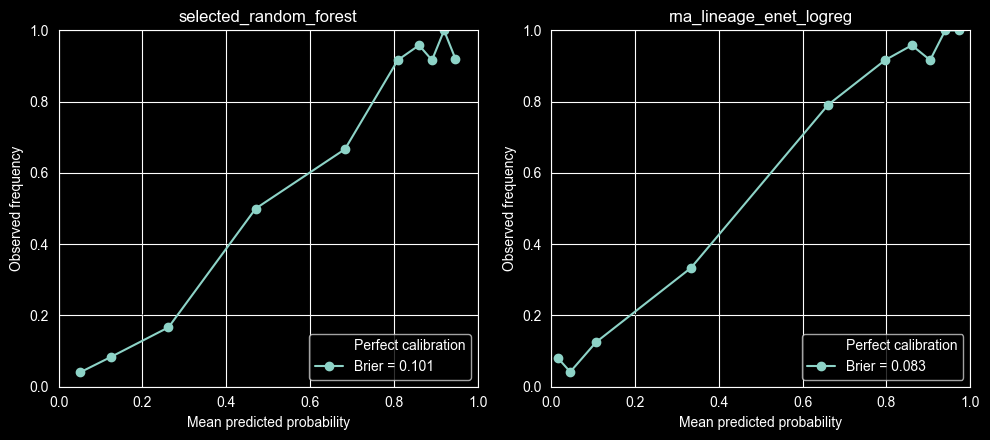

Brier scores on held-out test set (lower is better):


,model,test_brier_score
0,selected_random_forest,0.1013
1,rna_lineage_enet_logreg,0.0833


In [13]:
brier_df = None

calibration_models = []
if primary_clean_model is not None:
    calibration_models.append(primary_clean_model)
if overall_best_model is not None and overall_best_model != primary_clean_model:
    calibration_models.append(overall_best_model)
calibration_models = [m for m in calibration_models if m in final_probs_test and m != "dummy_prior"]

if calibration_models:
    fig, axes = plt.subplots(
        1, len(calibration_models),
        figsize=(5 * len(calibration_models), 4.5),
        squeeze=False,
    )
    brier_rows = []
    for ax, mname in zip(axes[0], calibration_models):
        prob = final_probs_test[mname]
        prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
        brier = brier_score_loss(y_test, prob)
        brier_rows.append({"model": mname, "test_brier_score": brier})

        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
        ax.plot(prob_pred, prob_true, "o-", label=f"Brier = {brier:.3f}")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Observed frequency")
        ax.set_title(mname)
        ax.legend(loc="lower right")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    brier_df = pd.DataFrame(brier_rows)
    print("Brier scores on held-out test set (lower is better):")
    display(brier_df.round(4))
else:
    print("No calibration-eligible models available.")


## 8. Label-strictness sensitivity analysis

The EDA builds three labels: `TP53_mut_any`, `TP53_mut_nonsyn`, and `TP53_mut_lof` — precisely to
test whether model results are robust to how aggressively we define the mutant class. The
headline result above uses `TP53_mut_nonsyn`. Here we rerun a compact registry (lineage
baseline + two RNA-only LR variants) on each label and report both validation and test
metrics.

Test AUPRC is the trustworthy column. If the lineage baseline's test AUPRC and the
RNA-only model's test AUPRC move together across labels, part of the headline signal is
likely driven by mutation-call quality rather than TP53 biology.


In [14]:
label_sensitivity = None

label_sensitivity_rows = []
for alt_label in CONFIG["alt_labels_for_sensitivity"]:
    if alt_label not in sample_meta.columns:
        print(f"Skipping {alt_label}: not in sample metadata.")
        continue
    y_alt = sample_meta[alt_label].astype(int)
    try:
        y_train_alt = y_alt.loc[X_train_model.index]
        y_val_alt = y_alt.loc[X_val_filt.index]
        y_test_alt = y_alt.loc[X_test_filt.index]
    except KeyError:
        print(f"Skipping {alt_label}: could not align to split indices.")
        continue

    if min(y_train_alt.nunique(), y_val_alt.nunique(), y_test_alt.nunique()) < 2:
        print(f"Skipping {alt_label}: at least one split has only one class.")
        continue

    y_trva_alt = pd.concat([y_train_alt, y_val_alt], axis=0)

    for model_name in CONFIG["label_sensitivity_models"]:
        if model_name not in candidate_specs:
            continue
        spec = candidate_specs[model_name]

        # Train with hyperparameter search on this label
        row, obj = fit_search_validate(
            f"{model_name}__{alt_label}", spec,
            spec["train_X"], y_train_alt,
            spec["val_X"], y_val_alt,
            cv=cv,
        )

        # Refit on train+val with chosen hyperparameters and evaluate on test
        fitted = clone(spec["estimator"]).set_params(**obj["best_params"])
        fitted.fit(spec["trva_X"], y_trva_alt)
        prob_test = infer_probabilities(fitted, spec["test_X"])
        test_row = evaluate_probs(
            y_test_alt, prob_test, obj["threshold"], "test",
            f"{model_name}__{alt_label}",
        )
        label_sensitivity_rows.append({
            "label": alt_label,
            "model": model_name,
            "val_auprc": row["auprc"],
            "val_auroc": row["auroc"],
            "test_auprc": test_row["auprc"],
            "test_auroc": test_row["auroc"],
            "n_train_pos": int(y_train_alt.sum()),
            "n_train_neg": int(len(y_train_alt) - y_train_alt.sum()),
            "n_test_pos": int(y_test_alt.sum()),
            "pct_train_pos": float(y_train_alt.mean()),
        })

if label_sensitivity_rows:
    label_sensitivity = (
        pd.DataFrame(label_sensitivity_rows)
        .sort_values(["label", "test_auprc"], ascending=[True, False])
        .reset_index(drop=True)
    )
    print(f"[data_mode={data_mode}]  Label-strictness sensitivity (test metrics are the trustworthy column):")
    display(label_sensitivity.round(4))
else:
    print("No label-sensitivity rows were produced.")


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_m

[data_mode=raw_reconstructed]  Label-strictness sensitivity (test metrics are the trustworthy column):


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,label,model,val_auprc,val_auroc,test_auprc,test_auroc,n_train_pos,n_train_neg,n_test_pos,pct_train_pos
0,TP53_mut_any,selected_enet_logreg,0.8896,0.8739,0.9547,0.9344,690,434,149,0.6139
1,TP53_mut_any,selected_l2_logreg,0.8849,0.8797,0.9529,0.9338,690,434,149,0.6139
2,TP53_mut_any,lineage_logreg,0.7253,0.6728,0.8595,0.7954,690,434,149,0.6139
3,TP53_mut_lof,selected_enet_logreg,0.5452,0.8089,0.7664,0.9209,249,875,61,0.2215
4,TP53_mut_lof,selected_l2_logreg,0.5097,0.7956,0.7581,0.9184,249,875,61,0.2215
5,TP53_mut_lof,lineage_logreg,0.2755,0.6135,0.3576,0.6628,249,875,61,0.2215
6,TP53_mut_nonsyn,selected_enet_logreg,0.8896,0.8739,0.9547,0.9344,690,434,149,0.6139
7,TP53_mut_nonsyn,selected_l2_logreg,0.8849,0.8797,0.9529,0.9338,690,434,149,0.6139
8,TP53_mut_nonsyn,lineage_logreg,0.7253,0.6728,0.8595,0.7954,690,434,149,0.6139


## 9. Nested grouped CV with lineage as the grouping variable

This section uses `StratifiedGroupKFold` on the combined train + validation data, with
lineage as the grouping variable, and runs a full inner-CV hyperparameter search per outer
fold. The test set is left untouched.

Interpretation:
- If performance stays strong here, RNA signal is less dependent on cross-lineage shortcuts.
- If performance drops sharply versus the random-split results above, the random split was probably benefiting from lineage structure.


In [15]:
grouped_cv_summary = None
grouped_cv_predictions = None
grouped_cv_folds = None

if lineage_col is not None:
    grouped_groups = (
        sample_meta.loc[X_trva_filt.index, lineage_col].fillna("Unknown").astype(str)
    )
    grouped_candidate_names = []
    for name in val_results.loc[
        val_results["family"].isin({"rna_selected", "rna_pca", "rna_residualized"})
        & ~val_results["model"].isin({"soft_vote_rna_topk"}),
        "model",
    ].tolist():
        if name not in grouped_candidate_names:
            grouped_candidate_names.append(name)
        if len(grouped_candidate_names) >= 3:
            break

    grouped_rows = []
    grouped_pred_frames = []
    grouped_fold_frames = []
    for model_name in grouped_candidate_names:
        spec = candidate_specs[model_name]
        try:
            summary_row, pred_df, fold_df = run_grouped_nested_cv(
                model_name, spec,
                spec["trva_X"], y_trva,
                grouped_groups.loc[spec["trva_X"].index],
                outer_splits=CONFIG["grouped_outer_splits"],
                inner_splits=CONFIG["grouped_inner_splits"],
                random_state=RNG + 101,
            )
            grouped_rows.append(summary_row)
            grouped_pred_frames.append(pred_df)
            grouped_fold_frames.append(fold_df)
        except Exception as exc:
            print(f"Grouped evaluation skipped for {model_name}: {exc}")

    if grouped_rows:
        grouped_cv_summary = (
            pd.DataFrame(grouped_rows)
            .sort_values(["auprc", "auroc", "balanced_acc"], ascending=False)
            .reset_index(drop=True)
        )
        grouped_cv_predictions = (
            pd.concat(grouped_pred_frames)
            .reset_index()
            .rename(columns={"index": "ModelID"})
        )
        grouped_cv_folds = pd.concat(grouped_fold_frames).reset_index(drop=True)
        print(f"[data_mode={data_mode}]  Nested grouped CV summary (lineage-aware evaluation):")
        display(grouped_cv_summary.round(4))
    else:
        print("No grouped CV results were produced.")
else:
    print("Grouped lineage-aware evaluation skipped because no lineage column is available.")


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_m

[data_mode=raw_reconstructed]  Nested grouped CV summary (lineage-aware evaluation):


/Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,split,threshold,auroc,auprc,balanced_acc,f1,precision,recall,specificity,tp,fp,tn,fn,family,n_outer_folds,n_samples,mean_fold_cv_best_score
0,selected_enet_logreg,grouped_cv,0.525,0.9038,0.9149,0.8570,0.8897,0.8892,0.8902,0.8239,746,93,435,92,rna_selected,5,1366,0.9196
1,selected_linear_svm,grouped_cv,0.505,0.8890,0.8976,0.8416,0.8841,0.8678,0.9010,0.7822,755,115,413,83,rna_selected,5,1366,0.8969
2,pca_logreg,grouped_cv,0.060,0.8117,0.8648,0.7623,0.7970,0.8362,0.7613,0.7633,638,125,403,200,rna_pca,5,1366,0.8540


## 10. Final comparison across reported analyses

The `uses_lineage_at_inference` column is now derived from each model's family, rather than
hard-coded, so the residualized model and the RNA+lineage model correctly show `True`.


In [16]:
def _row_for(model_name):
    """Return (val_auprc, test_row, family) for a named model, or None if missing."""
    if model_name is None or model_name not in test_results["model"].values:
        return None
    test_row = test_results.loc[test_results["model"].eq(model_name)].iloc[0]
    val_row = val_results.loc[val_results["model"].eq(model_name)]
    val_auprc = float(val_row["auprc"].iloc[0]) if len(val_row) else np.nan
    family = val_row["family"].iloc[0] if len(val_row) else "unknown"
    return val_auprc, test_row, family


final_comparison_rows = []
for label, model_name, goal, note in [
    ("Dummy prior", "dummy_prior",
     "Sanity baseline", "Class-prior baseline."),
    ("Lineage-only logistic regression", "lineage_logreg",
     "Confounding baseline", "How far can lineage alone go? RNA must beat this convincingly."),
    (f"Primary clean RNA-only: {primary_clean_model}", primary_clean_model,
     "Primary RNA-only benchmark", "Headline result for the RNA-only task."),
    (f"Overall best validation: {overall_best_model}", overall_best_model,
     "Upper bound under this split", "May use lineage and/or ensembling."),
]:
    got = _row_for(model_name)
    if got is None:
        continue
    val_auprc, test_row, family = got
    final_comparison_rows.append({
        "method": label,
        "uses_lineage_at_inference": family_uses_lineage_at_inference(family),
        "family": family,
        "main_goal": goal,
        "validation_auprc": val_auprc,
        "test_auprc": test_row["auprc"],
        "test_auroc": test_row["auroc"],
        "notes": note,
    })

if grouped_cv_summary is not None and primary_clean_model in grouped_cv_summary["model"].values:
    r = grouped_cv_summary.loc[grouped_cv_summary["model"].eq(primary_clean_model)].iloc[0]
    family = val_results.loc[val_results["model"].eq(primary_clean_model), "family"].iloc[0]
    final_comparison_rows.append({
        "method": f"Grouped CV: {primary_clean_model}",
        "uses_lineage_at_inference": family_uses_lineage_at_inference(family),
        "family": family,
        "main_goal": "Lineage-aware generalization check",
        "validation_auprc": np.nan,
        "test_auprc": r["auprc"],
        "test_auroc": r["auroc"],
        "notes": "Nested grouped CV on train+val; test set untouched.",
    })

final_comparison = pd.DataFrame(final_comparison_rows)
print(f"[data_mode={data_mode}]  Final comparison table:")
display(final_comparison.round(4))


[data_mode=raw_reconstructed]  Final comparison table:


,method,uses_lineage_at_inference,family,main_goal,validation_auprc,test_auprc,test_auroc,notes
0,Dummy prior,False,baseline,Sanity baseline,0.6116,0.6157,0.5000,Class-prior baseline.
1,Lineage-only logistic regression,True,lineage,Confounding baseline,0.7253,0.8595,0.7954,How far can lineage alone go? RNA must beat th...
2,Primary clean RNA-only: selected_random_forest,False,rna_tree,Primary RNA-only benchmark,0.8966,0.9267,0.9203,Headline result for the RNA-only task.
3,Overall best validation: rna_lineage_enet_logreg,True,rna_plus_lineage,Upper bound under this split,0.8972,0.9650,0.9466,May use lineage and/or ensembling.


## 11. Save artifacts for reporting and downstream analysis

In [17]:
val_results.to_csv(PROC / "ccle_revised_global_validation_results.csv", index=False)
test_results.to_csv(PROC / "ccle_revised_global_test_results.csv", index=False)
ci_summary.to_csv(PROC / "ccle_revised_global_test_bootstrap_ci.csv", index=False)

if grouped_cv_summary is not None:
    grouped_cv_summary.to_csv(PROC / "ccle_revised_grouped_cv_summary.csv", index=False)
if grouped_cv_predictions is not None:
    grouped_cv_predictions.to_csv(PROC / "ccle_revised_grouped_cv_predictions.csv", index=False)
if grouped_cv_folds is not None:
    grouped_cv_folds.to_csv(PROC / "ccle_revised_grouped_cv_fold_metrics.csv", index=False)

if coef_table is not None:
    coef_table.to_csv(PROC / "ccle_revised_primary_clean_coefficients.csv")
if pca_gene_weights is not None:
    pca_gene_weights.to_csv(PROC / "ccle_revised_primary_clean_pca_gene_weights.csv")
if feature_composition is not None:
    feature_composition.to_frame().T.to_csv(PROC / "ccle_revised_top_feature_composition.csv")
if per_lineage_primary is not None:
    per_lineage_primary.to_csv(PROC / "ccle_revised_primary_clean_per_lineage_test.csv", index=False)
if outlier_sensitivity is not None:
    outlier_sensitivity.to_frame().T.to_csv(PROC / "ccle_revised_outlier_sensitivity.csv")
if brier_df is not None:
    brier_df.to_csv(PROC / "ccle_revised_test_brier_scores.csv", index=False)
if label_sensitivity is not None:
    label_sensitivity.to_csv(PROC / "ccle_revised_label_sensitivity.csv", index=False)

best_params_export = pd.DataFrame([
    {
        "model": name,
        "family": obj.get("family"),
        "best_params_json": json.dumps(obj.get("best_params", {}), sort_keys=True, default=str),
        "description": obj.get("description", ""),
    }
    for name, obj in validation_objects.items()
])
best_params_export.to_csv(PROC / "ccle_revised_best_params.csv", index=False)

catalog_export = pd.DataFrame([
    {
        "model": name,
        "family": spec["family"],
        "ensemble_eligible": spec["ensemble_eligible"],
        "description": spec["description"],
    }
    for name, spec in candidate_specs.items()
])
catalog_export.to_csv(PROC / "ccle_revised_registry_catalog.csv", index=False)

final_predictions_global = pd.DataFrame(index=X_test_filt.index)
final_predictions_global["y_true"] = y_test
for model_name, prob in final_probs_test.items():
    final_predictions_global[f"prob_{model_name}"] = prob
save_parquet_with_id(final_predictions_global, "ccle_revised_global_test_predictions.parquet")

final_comparison.to_csv(PROC / "ccle_revised_final_comparison.csv", index=False)

summary = {
    "data_mode": data_mode,
    "data_mode_caveat": (
        "fallback_selected_only uses globally pre-selected genes (not refit per CV fold); "
        "validation and test metrics inherit the EDA's globally-selected-genes caveat."
        if data_mode == "fallback_selected_only"
        else "raw_reconstructed refits supervised feature selection per CV fold."
    ),
    "label_col": label_col,
    "lineage_col": lineage_col,
    "primary_clean_model": primary_clean_model,
    "primary_clean_family": (
        val_results.loc[val_results["model"].eq(primary_clean_model), "family"].iloc[0]
        if primary_clean_model is not None else None
    ),
    "primary_clean_uses_lineage_at_inference": (
        bool(family_uses_lineage_at_inference(
            val_results.loc[val_results["model"].eq(primary_clean_model), "family"].iloc[0]
        )) if primary_clean_model is not None else None
    ),
    "overall_best_validation_model": overall_best_model,
    "per_lineage_auprc_spread": (
        float(auprc_spread) if auprc_spread is not None else None
    ),
}
with open(PROC / "ccle_revised_run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved revised outputs to processed/.")
print(json.dumps(summary, indent=2, default=str))


Saved revised outputs to processed/.
{
  "data_mode": "raw_reconstructed",
  "data_mode_caveat": "raw_reconstructed refits supervised feature selection per CV fold.",
  "label_col": "TP53_mut_nonsyn",
  "lineage_col": "OncotreeLineage",
  "primary_clean_model": "selected_random_forest",
  "primary_clean_family": "rna_tree",
  "primary_clean_uses_lineage_at_inference": false,
  "overall_best_validation_model": "rna_lineage_enet_logreg",
  "per_lineage_auprc_spread": 0.5833333333333336
}
